# Devanagari Dataset Exploration

This notebook explores the Devanagari character dataset structure and loads the data for training and testing.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import pandas as pd

# Set paths
DATA_DIR = Path('../data/devanagari')
TRAIN_DIR = DATA_DIR / 'Train'
TEST_DIR = DATA_DIR / 'Test'

print(f"Data directory: {DATA_DIR}")
print(f"Train directory exists: {TRAIN_DIR.exists()}")
print(f"Test directory exists: {TEST_DIR.exists()}")


Data directory: ..\data\devanagari
Train directory exists: True
Test directory exists: True


In [2]:
# Get all class folders
train_classes = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
test_classes = sorted([d.name for d in TEST_DIR.iterdir() if d.is_dir()])

print(f"Number of classes: {len(train_classes)}")
print(f"\nClasses:")
for i, cls in enumerate(train_classes, 1):
    print(f"{i}. {cls}")


Number of classes: 46

Classes:
1. character_10_yna
2. character_11_taamatar
3. character_12_thaa
4. character_13_daa
5. character_14_dhaa
6. character_15_adna
7. character_16_tabala
8. character_17_tha
9. character_18_da
10. character_19_dha
11. character_1_ka
12. character_20_na
13. character_21_pa
14. character_22_pha
15. character_23_ba
16. character_24_bha
17. character_25_ma
18. character_26_yaw
19. character_27_ra
20. character_28_la
21. character_29_waw
22. character_2_kha
23. character_30_motosaw
24. character_31_petchiryakha
25. character_32_patalosaw
26. character_33_ha
27. character_34_chhya
28. character_35_tra
29. character_36_gya
30. character_3_ga
31. character_4_gha
32. character_5_kna
33. character_6_cha
34. character_7_chha
35. character_8_ja
36. character_9_jha
37. digit_0
38. digit_1
39. digit_2
40. digit_3
41. digit_4
42. digit_5
43. digit_6
44. digit_7
45. digit_8
46. digit_9


In [3]:
# Count images per class
class_counts = {}
for cls in train_classes:
    train_path = TRAIN_DIR / cls
    test_path = TEST_DIR / cls
    train_count = len(list(train_path.glob('*.png')))
    test_count = len(list(test_path.glob('*.png')))
    class_counts[cls] = {'train': train_count, 'test': test_count}

# Create DataFrame
df = pd.DataFrame(class_counts).T
df.index.name = 'Class'
print(df.head(10))
print(f"\nTotal training images: {df['train'].sum()}")
print(f"Total test images: {df['test'].sum()}")


                       train  test
Class                             
character_10_yna        1700   300
character_11_taamatar   1700   300
character_12_thaa       1700   300
character_13_daa        1700   300
character_14_dhaa       1700   300
character_15_adna       1700   300
character_16_tabala     1700   300
character_17_tha        1700   300
character_18_da         1700   300
character_19_dha        1700   300

Total training images: 78200
Total test images: 13800


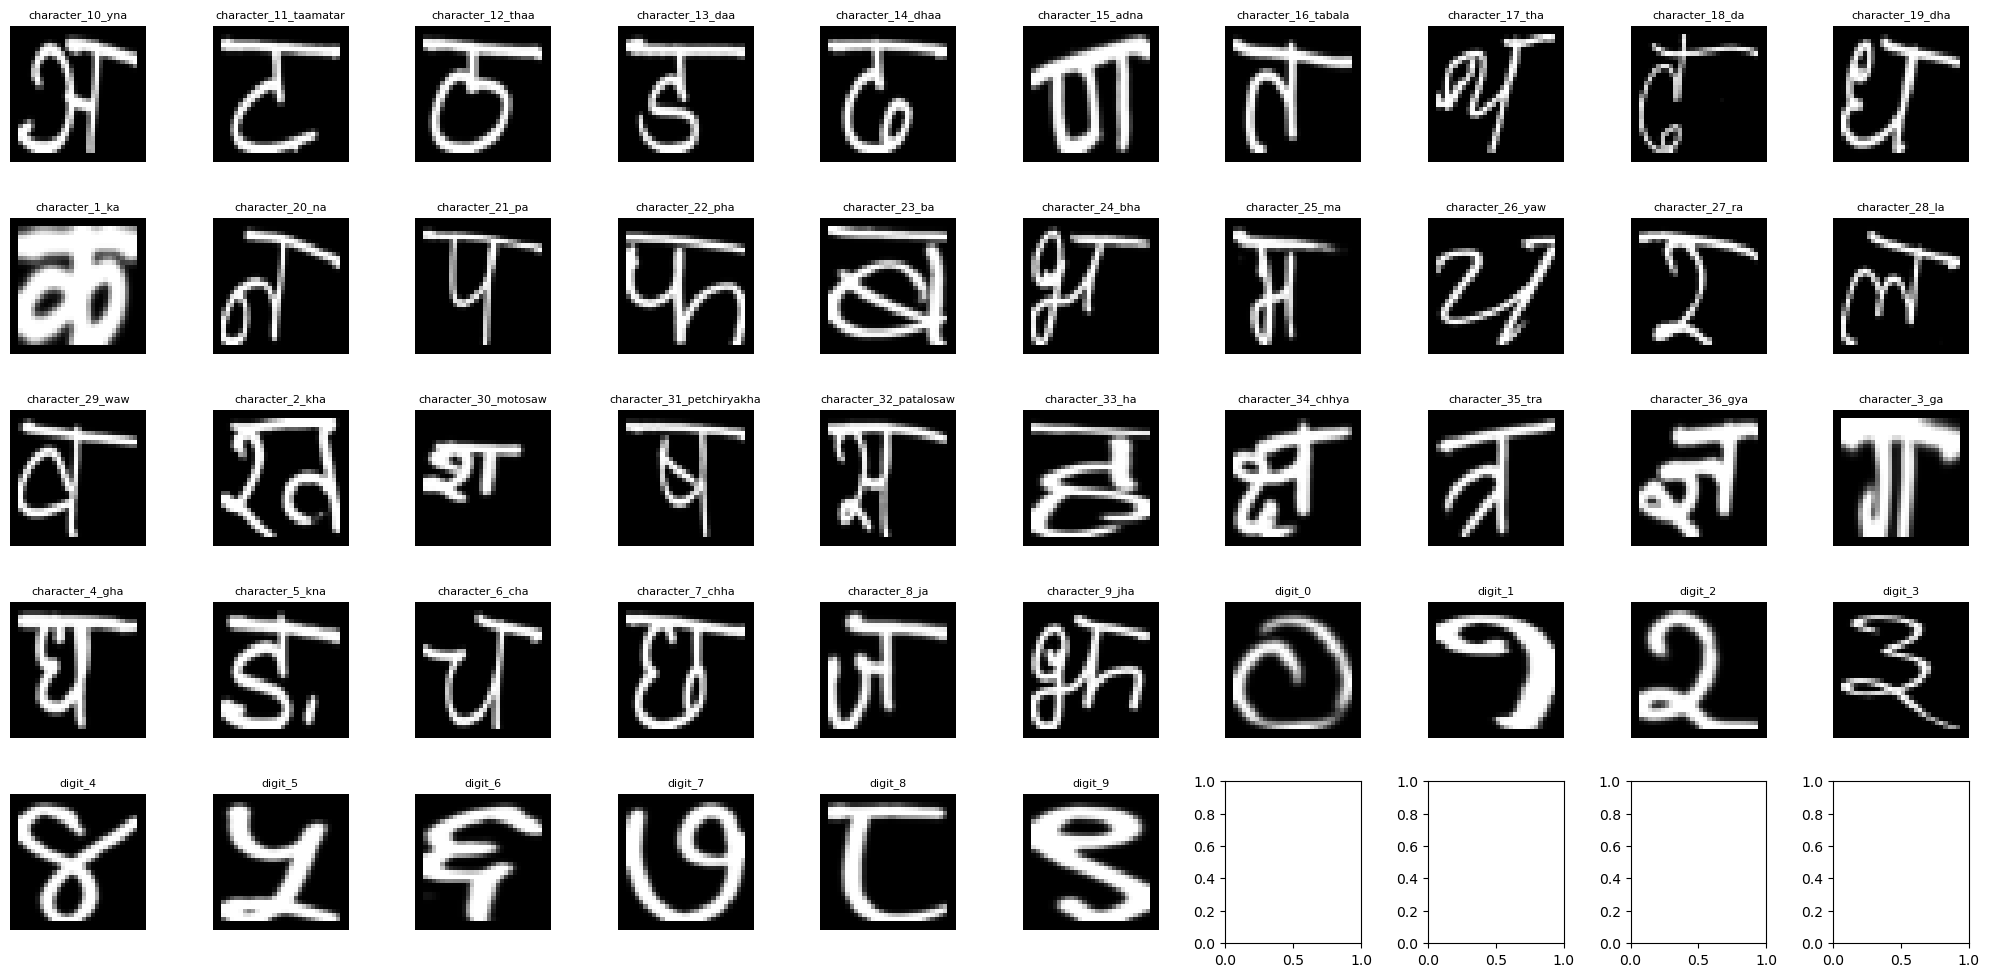

In [4]:
# Visualize sample images from each class
fig, axes = plt.subplots(5, 10, figsize=(20, 10))
axes = axes.flatten()

for idx, cls in enumerate(train_classes[:50]):  # Show first 50 classes
    cls_path = TRAIN_DIR / cls
    img_files = list(cls_path.glob('*.png'))
    if img_files:
        img = Image.open(img_files[0])
        axes[idx].imshow(img, cmap='gray')
        axes[idx].set_title(cls, fontsize=8)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()


In [5]:
# Check image dimensions
sample_img = Image.open(list((TRAIN_DIR / train_classes[0]).glob('*.png'))[0])
print(f"Image size: {sample_img.size}")
print(f"Image mode: {sample_img.mode}")

# Load a sample image as array
sample_array = np.array(sample_img)
print(f"Array shape: {sample_array.shape}")
print(f"Array dtype: {sample_array.dtype}")
print(f"Min value: {sample_array.min()}, Max value: {sample_array.max()}")


Image size: (32, 32)
Image mode: L
Array shape: (32, 32)
Array dtype: uint8
Min value: 0, Max value: 255


In [6]:
# Create class to label mapping
class_to_idx = {cls: idx for idx, cls in enumerate(train_classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

print(f"Total classes: {len(class_to_idx)}")
print(f"\nFirst 10 class mappings:")
for i, (cls, idx) in enumerate(list(class_to_idx.items())[:10]):
    print(f"{idx}: {cls}")

# Save mappings for use in other notebooks
import pickle
with open('../utils/class_mappings.pkl', 'wb') as f:
    pickle.dump({'class_to_idx': class_to_idx, 'idx_to_class': idx_to_class, 'classes': train_classes}, f)
    
print("\nClass mappings saved to ../utils/class_mappings.pkl")


Total classes: 46

First 10 class mappings:
0: character_10_yna
1: character_11_taamatar
2: character_12_thaa
3: character_13_daa
4: character_14_dhaa
5: character_15_adna
6: character_16_tabala
7: character_17_tha
8: character_18_da
9: character_19_dha

Class mappings saved to ../utils/class_mappings.pkl
